In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

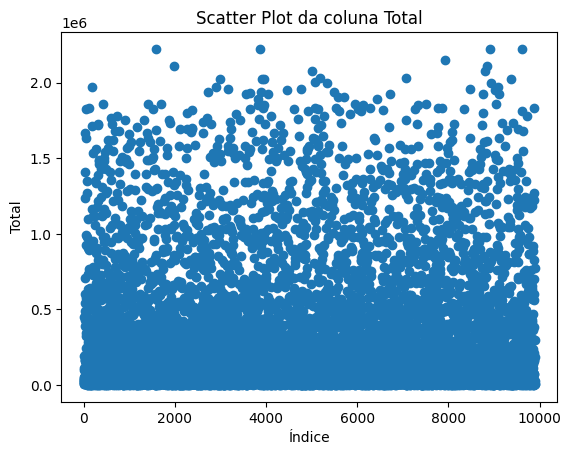

In [40]:
df = pd.read_csv('../datasets/vendas_2023_2024.csv')

x = df.index
y = df['total']
plt.scatter(x, y)

plt.xlabel('Índice')
plt.ylabel('Total')
plt.title('Scatter Plot da coluna Total')

plt.show()

Existem valores bem acima da média observada. Isso é mais facilmente observado ao fazer uma análise grafica da coluna 'total'. Apesar de também ser possível observar valores muito abaixo da média, não considero que esses valores sejam outliers, isso é facilmente observável ao plotar o gráfico de dispersão.﻿Os dados apresentam um problema grande em relação ao formato da data, a coluna está em diversos formatos, sem uma padronização. Além disso, há algumas linhas nulas.﻿Por conta desses problemas, pode ser necessário uma normalização da coluna data e uma limpeza das linhas nulas.

In [41]:
def rename_column(text: str):
    if text.startswith('elet'):
        return 'eletrônicos'
    elif text.startswith('prop'):
        return 'propulsão'
    elif text.startswith('enc') or text.startswith('anc'):
        return 'ancoragem'

In [42]:
df_products = pd.read_csv('../datasets/produtos_raw.csv')
df_products['code'] = df_products['code'].astype(int)
df_products['price'] = df_products['price'].str.removeprefix('R$ ').astype(float)
df_products['actual_category'] = df_products['actual_category'].str.replace(' ', '').str.lower()
df_products['actual_category'] = df_products['actual_category'].apply(rename_column)
display(len(df_products))
df_products.drop_duplicates(inplace=True)
display(len(df_products))

157

150

7 linhas duplicadas foram removidas

In [43]:
df_products

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,33122.52,1,eletrônicos
1,Transponder Furuno Marlin,13998.15,2,eletrônicos
2,Radar Furuno Pulse Leviathan,9024.19,3,eletrônicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,eletrônicos
4,Piloto Automático Furuno Storm,23669.01,5,eletrônicos
...,...,...,...,...
152,Corrente Delta Vox Ion,495.98,146,ancoragem
153,Corrente Danforth Force Leviathan Impulse,3030.08,147,ancoragem
154,Âncora Delta Force Barracuda Mako,4785.56,148,ancoragem
155,Cabo de Nylon Bruce Core,1163.62,149,ancoragem


In [44]:
with open('../datasets/custos_importacao.json', 'r') as f:
    import_costs = json.load(f)

line = {}
lines = []
columns = ['product_id', 'product_name', 'category', 'start_date', 'usd_price']
for elem in import_costs:
    line['product_id'] = elem['product_id']
    line['product_name'] = elem['product_name']
    line['category'] = elem['category']
    line['start_date'] = elem['historic_data'][0]['start_date']
    line['usd_price'] = elem['historic_data'][0]['usd_price']
    lines.append(line.copy())

In [45]:
df_import_costs = pd.DataFrame(lines)
df_import_costs['start_date'] = pd.to_datetime(df_import_costs['start_date'], dayfirst=True)
df_import_costs.to_csv('../datasets/custos_importacao.csv', sep=',', index=False,)
df_import_costs

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,10583.63
1,2,Transponder Furuno Marlin,eletrônicos,2017-11-23,4325.09
2,3,Radar Furuno Pulse Leviathan,eletrônicos,2016-04-12,2549.21
3,4,Rádio AIS Hydro Tidal Zen,eletrônicos,2016-03-04,909.55
4,5,Piloto Automático Furuno Storm,eletrônicos,2016-02-10,6006.45
...,...,...,...,...,...
145,146,Corrente Delta Vox Ion,ancoragem,2016-05-03,139.54
146,147,Corrente Danforth Force Leviathan Impulse,ancoragem,2016-05-13,864.87
147,148,Âncora Delta Force Barracuda Mako,ancoragem,2017-06-06,1458.52
148,149,Cabo de Nylon Bruce Core,ancoragem,2016-02-19,287.41
